![image.png](https://i.imgur.com/nUFj4UV.png)

#  Week 2 Day 1 - اكتشاف سوسن | Explore Iris
---

<div dir="rtl">

تُعد **مجموعة بيانات Iris** من أشهر مجموعات البيانات في تعلم الآلة. قدمها **رونالد أ. فيشر عام 1936،** **وتحتوي على 150** عينة من **ثلاثة أنواع من أزهار السوسن**، ويمثل كل منها **أربع خصائص عددية**. وتُستخدم على نطاق واسع كنقطة بداية لتعلم الآلة لأنها صغيرة، ونظيفة، وسهلة الفهم، مما يجعلها مناسبة لتعلم استكشاف البيانات، وتمثيلها، وتصنيفها.

في تعلم الآلة، **الميزة (Feature)** هي خاصية أو صفة قابلة للقياس تصف عينة البيانات وتُستخدم كمدخل للنموذج. وفي مجموعة بيانات Iris، يتم وصف كل زهرة باستخدام أربع خصائص.

| الخاصية                   |                   مثال (سم) |
| ------------------------- |---------------------------: |
| طول السبلة (Sepal Length) |<span dir="ltr">`5.1`</span> |
| عرض السبلة (Sepal Width)  |<span dir="ltr">`3.5`</span> |
| طول البتلة (Petal Length) |<span dir="ltr">`1.4`</span> |
| عرض البتلة (Petal Width)  |<span dir="ltr">`0.2`</span> |

**الفئة (Label) أو الهدف (Target)** هي القيمة التي يحاول نموذج تعلم الآلة التنبؤ بها. وفي مجموعة بيانات Iris، يمثل الهدف نوع الزهرة، والذي ينتمي إلى إحدى ثلاث فئات.

| الفئة          | الوصف                         |
| -------------- | ----------------------------- |
| **Setosa**     | زهرة السوسن من نوع Setosa     |
| **Versicolor** | زهرة السوسن من نوع Versicolor |
| **Virginica**  | زهرة السوسن من نوع Virginica  |

</div>

The **Iris dataset** is one of the most well-known datasets in machine learning. It was introduced by **Ronald A. Fisher** in **1936** and contains **150 flower samples** from **three Iris species**, each described by **four numerical features**. It is widely used as an introduction to machine learning because it is small, clean, and easy to understand, making it ideal for learning data exploration, visualization, and classification.

In machine learning, a **feature** is a measurable property or characteristic of a data sample that is used as input to a model. In the Iris dataset, each flower is described by four features.

| Feature      | Example (cm) |
| ------------ | -----------: |
| Sepal Length |        `5.1` |
| Sepal Width  |        `3.5` |
| Petal Length |        `1.4` |
| Petal Width  |        `0.2` |

The **label** (or **target**) is the value that a machine learning model tries to predict. In the Iris dataset, the target is the species of the flower, which belongs to one of three classes.

| Class          | Description     |
| -------------- | --------------- |
| **Setosa**     | Iris Setosa     |
| **Versicolor** | Iris Versicolor |
| **Virginica**  | Iris Virginica  |

# **📌 تحميل مجموعة البيانات | Donwloading the Dataset**

In [ ]:
# قراءة مجموعة البيانات من الملف | reading the dataset from the file

import pandas as pd
df = pd.read_csv("iris.csv")

print(len(df))

150


In [1]:
# حمل مجموعة البيانات من كاغل | download the dataset from kaggle

#!pip install kagglehub --break-system-packages

import kagglehub
import pandas
import os

dataset_path = kagglehub.dataset_download('uciml/iris')
df = pandas.read_csv(os.path.join(dataset_path, 'Iris.csv')).drop(axis=1, columns='Id')

# make it similar to the file
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df['species'] = df['species'].replace('Iris-', '', regex=True)

print(len(df))

100%|██████████| 3.60k/3.60k [00:00<00:00, 2.18MB/s]

Extracting files...
150


# **📌 استكشاف | Exploring**

In [ ]:
df.head() # عرض العينات الخمس الأولى | display the first five samples
#df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
df.columns # عرض الأعمدة | display the columns
# لاحظ أن الأعمدي تحتوي على الميزات والهدف | notice that the columns contain the features and target

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [ ]:
df['species'].unique() # عرض القيم الفريدة | display the unique values

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [ ]:
features = df.drop(columns=['species'])

features[features <= 0].count() # عرض عدد القيم التي أصغر من أو تساوي صفر | display the count of values that are less than or equal to zero

sepal_length    150
sepal_width     150
petal_length    150
petal_width     150
dtype: int64

In [ ]:
# الطريقة 1 | Method 1:
# حساب عدد العينات التابعة لكل فئة من الزهور | calculating the number of samples belonging to each flower class

setosa = 0
versicolor = 0
virginica = 0

for s in df['species']:#.to_list(): This won't make any difference here...
    if s == "setosa":
        setosa = setosa + 1
    elif s == "versicolor":
        versicolor = versicolor + 1
    else:
        virginica = virginica + 1

print(setosa)
print(versicolor)
print(virginica)

50
50
50


In [ ]:
# الطريقة 2 | Method 2:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## **🔹 🧠 تمرين | Exercise**

<div dir="rtl">

1. عدد الصفوف والأعمدة في `df` (الشكل / shape).
2. أنواع بيانات كل عمود (`dtypes`).
3. هل توجد أي قيم مفقودة (`null`) في أي عمود؟
4. اكتب كودًا للتحقق مما إذا كانت هناك أي صفوف مكررة (duplicate rows) في `df`.

</div>

1. The number of rows and columns in `df` (its **shape**).
2. The data type of each column (`dtypes`).
3. Whether any column contains missing (`null`) values.
4. Write code to check whether `df` contains any **duplicate rows**.

In [ ]:
# TODO: أكتب الحل هنا | write the solution here

**✅ الحل | Solution**

In [ ]:
# 1. الشكل | shape
print(df.shape)

print('\n======================\n')

# 2. أنواع البيانات | dtypes
print(df.dtypes)

print('\n======================\n')

# 3. القيم المفقودة | missing values
print(df.isnull().sum())

print('\n======================\n')

# 4. الصفوف المكررة | duplicate rows
print(df.duplicated().sum())

(150, 5)


sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


1


# **📌 الإحصاءات الوصفية | Descriptive Statistics**

In [ ]:
# الطريقة 1 | Method 1:
print(sum(df['petal_length']) / len(df['petal_length'])) # متوسط طول البتلة | average petal length
print(min(df['petal_length'])) # أصغر طول البتلة | minimum petal length
print(max(df['petal_length'])) # أكبر طول البتلة | maximum petal length

3.7580000000000005
1.0
6.9


In [ ]:
# الطريقة 2 | Method 2:
print(f'Minimum:\n{features.min(axis=0)}\n') # أكبر قيمة لكل ميزة | maximum value for each feature
print(f'Maximum:\n{features.max(axis=0)}\n') # أصغر قيمة لكل ميزة | minimum value for each feature
print(f'Average:\n{features.mean(axis=0)}\n') # المتوسط لكل ميزة | average value for each feature
print(f'Standard Deviation:\n{features.std(axis=0)}\n') # الانحراف المعياري لكل ميزة | standard deviation value for each feature

Minimum:
sepal_length    4.3
sepal_width     2.0
petal_length    1.0
petal_width     0.1
dtype: float64

Maximum:
sepal_length    7.9
sepal_width     4.4
petal_length    6.9
petal_width     2.5
dtype: float64

Average:
sepal_length    5.843333
sepal_width     3.054000
petal_length    3.758667
petal_width     1.198667
dtype: float64

Standard Deviation:
sepal_length    0.828066
sepal_width     0.433594
petal_length    1.764420
petal_width     0.763161
dtype: float64



In [ ]:
# الحد الأدنى والأقصى لكل ميزة لكل فئة | min and max for each feature per class
df.groupby('species')[df.columns.drop('species')].agg(['min', 'max'])

sepal_length      sepal_width      petal_length      petal_width  \
                    min  max         min  max          min  max         min   
species                                                                       
setosa              4.3  5.8         2.3  4.4          1.0  1.9         0.1   
versicolor          4.9  7.0         2.0  3.4          3.0  5.1         1.0   
virginica           4.9  7.9         2.2  3.8          4.5  6.9         1.4   

                 
            max  
species          
setosa      0.6  
versicolor  1.8  
virginica   2.5

<div dir="rtl">

تتداخل نطاقات **طول السبلة (Sepal Length)** و**عرض السبلة (Sepal Width)** و**عرض البتلة (Petal Width)** بشكل كبير بين الأنواع الثلاثة من Iris، مما يجعل التمييز بينها باستخدام أيٍ من هذه الخصائص وحدها أمرًا صعبًا. أما **طول البتلة (Petal Length)**، فإن نطاق قيمه يكاد لا يتداخل بين الفئات، مما يجعله قادرًا على الفصل بينها بوضوح أكبر. ولهذا السبب اختارت شجرة القرار طول البتلة باعتباره الخاصية الوحيدة اللازمة لإجراء التصنيف.

</div>

The ranges of **sepal length**, **sepal width**, and **petal width** overlap considerably between the three Iris species, making it difficult to distinguish the classes using these features alone. In contrast, the range of **petal length** shows little overlap, allowing it to separate the species much more clearly.

In [ ]:
# الطريقة 1 | Method 1:
# حساب متوسط طول البتلة لكل فئة من الزهور | calculate the average petal length for each class of flowers
for s in df['species'].unique():
    total = 0
    count = 0
    for i in range(len(df)):
        if df['species'][i] == s:
            total = total + df['petal_length'][i]
            count = count + 1
    print(f"Average petal length for '{s}' is: {total / count}")

Average petal length for 'setosa' is: 1.4620000000000002
Average petal length for 'versicolor' is: 4.26
Average petal length for 'virginica' is: 5.552


In [ ]:
# الطريقة 2 | Method 2:
# حساب المتوسط لكل الميزات لكل فئة من الزهور | calculate the average of all features for each class of flowers
df.groupby('species')[df.columns.drop('species')].mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


<div dir="rtl">

تُعد قيم **المتوسط (Mean)** لكلٍ من **طول السبلة (Sepal Length)** و**عرض السبلة (Sepal Width)** متقاربة نسبيًا بين الأنواع الثلاثة من Iris، مما يجعل هاتين الخاصيتين أقل فائدة في التمييز بين الفئات. في المقابل، فإن متوسطات **طول البتلة (Petal Length)** و**عرض البتلة (Petal Width)** أكثر تباعدًا، مما يساعد على التفريق بين الأنواع بشكل أفضل. وبشكل عام، كلما كانت متوسطات الخاصية متباعدة بين الفئات، كانت هذه الخاصية أكثر فائدة في التصنيف.

</div>

The **average (mean)** values of **sepal length** and **sepal width** are relatively close across the three Iris species, making these features less effective for distinguishing between classes. In contrast, the mean values of **petal length** and **petal width** are more separated, allowing them to better differentiate the species. Features with well-separated means generally provide more useful information for classification.

# **📌 الأنماط | Patterns**

<div dir="rtl">

**النمط (Pattern)** هو علاقة أو اتجاه يظهر في البيانات ويساعد على التمييز بين الفئات المختلفة. وتُعد الميزة **مفيدة** إذا كانت قيمها تختلف بوضوح بين الفئات، بينما تُعد **ضعيفة** إذا كانت قيمها متقاربة بينها.

#### **لماذا هذا مهم؟**
تساعد الخصائص المفيدة نماذج تعلم الآلة على التمييز بين الفئات بدقة أكبر، مما يؤدي غالبًا إلى تحسين أداء النموذج.

يساعدنا **المتوسط** (**Mean**) و**المدى** (**Range**) في معرفة مدى فائدة الخاصية في التمييز بين الفئات.

- يمثل **المتوسط** القيمة المتوسطة للخاصية داخل كل فئة. فإذا كانت متوسطات الفئات متباعدة، فإن الخاصية تكون غالبًا مفيدة للتصنيف.
- يمثل المدى (من أصغر قيمة إلى أكبر قيمة) انتشار قيم الخاصية. فإذا كان مدى كل فئة يتداخل قليلًا مع الفئات الأخرى، فإن الخاصية تستطيع التمييز بينها بوضوح، أما إذا كان التداخل كبيرًا فتكون الخاصية أقل فائدة.

</div>

A **pattern** is a relationship or trend in the data that helps us distinguish between different classes. A feature is considered **useful** if its values differ significantly across classes, and **weak** if its values are similar for all classes.

#### **Why is this useful?**
Useful features make it easier for machine learning models to correctly classify data, often leading to higher prediction accuracy.

The **mean** and **range** help us determine whether a feature is useful for distinguishing between classes.

- The mean represents the average value of a feature for each class. If the means of different classes are far apart, the feature is likely to be useful for classification.
- The range (minimum to maximum value) shows how the feature values are spread. If the ranges of different classes overlap very little, the feature can clearly separate the classes. Large overlap usually indicates a weaker feature.

/home/firas/.local/lib/python3.12/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


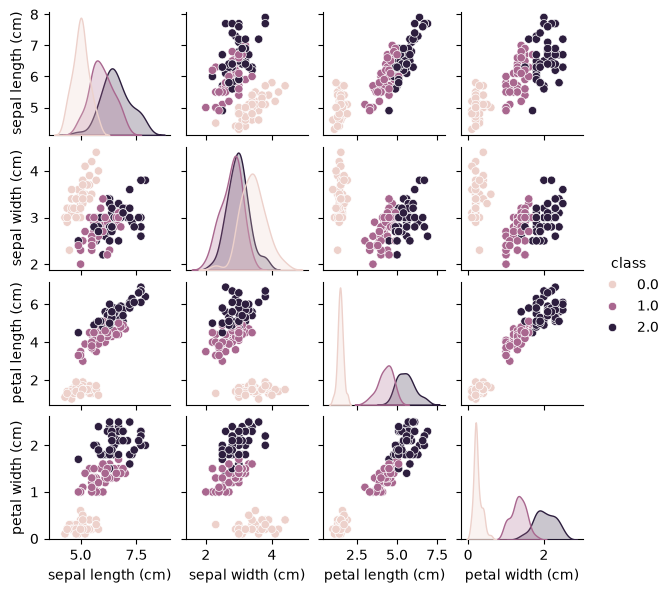

In [ ]:
#!pip install seaborn --break-system-packages

import seaborn as sns

sns.pairplot(df, hue='class', size=1.5)

<div dir="rtl">

يمثل هذا الشكل **مخطط الأزواج (Pair Plot)**، ويعرض العلاقة بين كل زوج من الخصائص بالإضافة إلى توزيع كل خاصية. ويمثل كل لون نوعًا مختلفًا من أزهار Iris. وتُعد الخصائص التي تُكوّن **مجموعات منفصلة بوضوح** (مثل **طول البتلة** و**عرض البتلة**) أكثر فائدة في التصنيف، بينما تكون الخصائص التي تُظهر **تداخلًا كبيرًا بين المجموعات** (مثل **طول السبلة** و**عرض السبلة**) أقل قدرة على التمييز بين الأنواع.

</div>

This figure is a **pair plot**, which shows the relationship between every pair of features and the distribution of each feature. Each color represents a different Iris species. Features whose classes form **well-separated clusters** (such as **petal length** and **petal width**) are more useful for classification, while features with **overlapping clusters** (such as **sepal length** and **sepal width**) are less effective at distinguishing between species.